## Prognose des Tinnitus Zustandes

# Prognose

# Vorbereitung für Modelle

In [1]:
# Bibliotheken laden
import pandas as pd
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
# Daten laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0.xes')
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

KeyError: 'time:timestamp'

In [8]:
# Konvertiere concept:name / score in Zahlen, bevor das Modell trainiert wird
df['concept:name_encoded'] = df['concept:name'].astype('category').cat.codes

KeyError: 'concept:name'

In [4]:
# Vorbereitung fürs Modell

# Konfiguration
WINDOW_SIZE = 10 # wie viele Einträge der Vergangenheit sollen beachtet werden? Die letzten X Einträge.
FEATURES_TO_LAG = ['q1', 'sound_norm', 'concept:name_encoded'] # Welche Spalten sollen in die Historie einfließen? Spalten einfach dazu- / wegnehmen.
TARGET_COL = 'q1'
USER_ID_COL = 'case:concept:name'
TIME_COL = 'time:timestamp'


# Erstellt für jeden User die letzten N Schritte als Features.
def create_lagged_features(df, window_size, features_to_lag, user_col, time_col):

    # Daten sortieren
    df = df.sort_values([user_col, time_col])
    df_result = df.copy()

    # Schleife über die in FEATURES_TO_LAG definierten Spalten
    for feature in features_to_lag:
        for i in range(1, window_size + 1):
            # Erstellt z.B. 'q1_lag1', 'sound_norm_lag1', 'score_lag1' usw.
            df_result[f'{feature}_lag{i}'] = df.groupby(user_col)[feature].shift(i)

    # Entfernen der Zeilen mit unvollständiger Historie
    df_result = df_result.dropna()

    return df_result


df_prepared = create_lagged_features(df, WINDOW_SIZE, FEATURES_TO_LAG, USER_ID_COL, TIME_COL)

In [5]:
# Teilt die Daten so, dass der letzte Eintrag jedes Users im Testset landet und der Rest im Training.
def split_by_last_event(df, user_col, time_col):

    # Sortieren
    df = df.sort_values([user_col, time_col])

    # Den letzten Eintrag pro User markieren
    last_indices = df.groupby(user_col).tail(1).index

    # Splitten
    test_df = df.loc[last_indices]
    train_df = df.drop(last_indices)

    return train_df, test_df

In [6]:
# Train Test Split

# Split in Training und Test
train_df, test_df = split_by_last_event(df_prepared, USER_ID_COL, TIME_COL)

# Features und Ziel definieren
# Alle Spalten, die 'lag' im Namen haben, sind unsere Input-Features
feature_cols = [col for col in df_prepared.columns if 'lag' in col]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen")
print(f"Testdaten: {X_test.shape[0]} Zeilen")

Trainingsdaten: 82268 Zeilen
Testdaten: 919 Zeilen


# Logistische Regession

In [7]:
# Baseline Modell das geschlagen werden muss / sollte

# Initialisierung
# 'balanced' passt die Gewichte automatisch an die Klassenverteilung an
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Training
model_lr.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistische Regession Klassifikationsbericht:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistische Regession Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.52      0.83      0.64       179
         1.0       0.95      0.81      0.88       740

    accuracy                           0.82       919
   macro avg       0.74      0.82      0.76       919
weighted avg       0.87      0.82      0.83       919

ROC-AUC Score: 0.9018


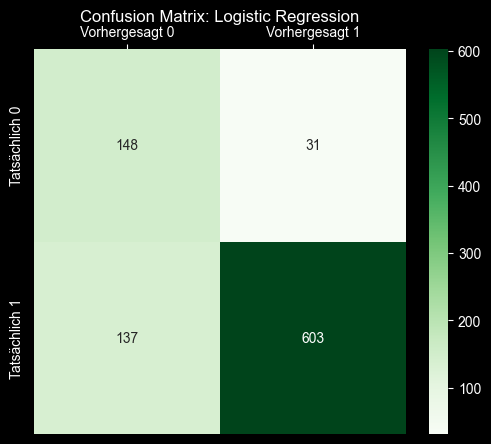

In [8]:
# Confusion Matrix ausgeben

# Matrix berechnen
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
                 xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
                 yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])
# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Confusion Matrix: Logistic Regression', pad=20)
plt.show()

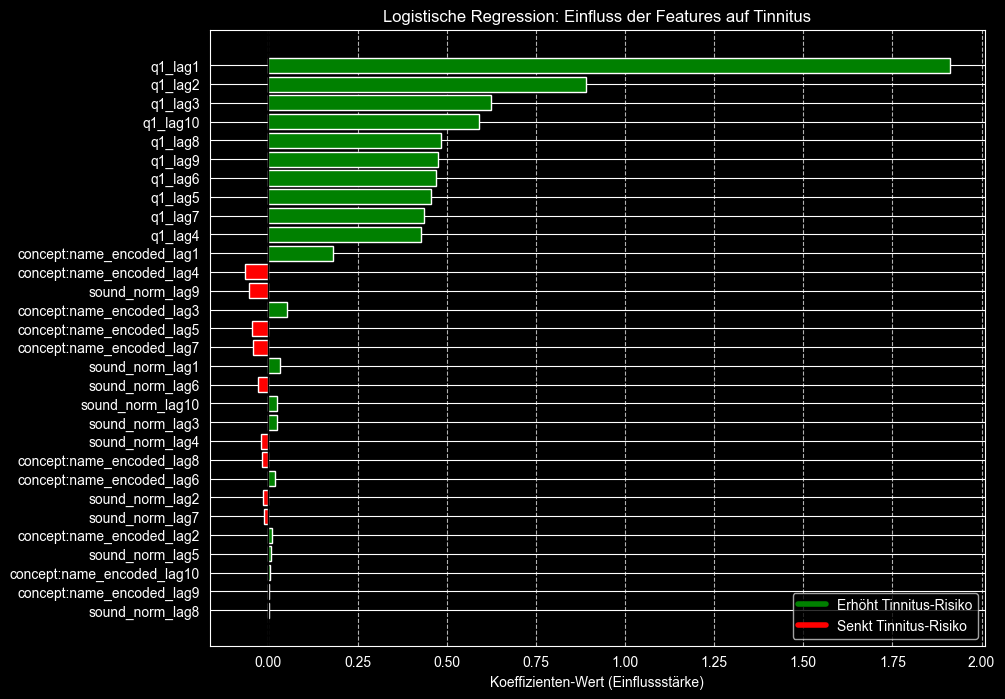

In [9]:
# schauen, was die Logistsche Regession genau gemacht hat

# Koeffizienten extrahieren
coefficients = model_lr.coef_[0]
feature_names = X_train.columns

# In DataFrame packen für einfacheres Sortieren
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=True).tail(30) # Top X Features

# Plot erstellen
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Koeffizienten-Wert (Einflussstärke)')
plt.title('Logistische Regression: Einfluss der Features auf Tinnitus')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legende manuell hinzufügen
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4)]
plt.legend(custom_lines, ['Erhöht Tinnitus-Risiko', 'Senkt Tinnitus-Risiko'])

plt.show()

# XG Boost

In [10]:
# Modell trainieren V1

# Initialisierung
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

# Training
model.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Wahrscheinlichkeiten für Klasse 1

# Evaluation
print("XG Boost Klassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

XG Boost Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.67      0.68      0.67       179
         1.0       0.92      0.92      0.92       740

    accuracy                           0.87       919
   macro avg       0.79      0.80      0.80       919
weighted avg       0.87      0.87      0.87       919

ROC-AUC Score: 0.8997


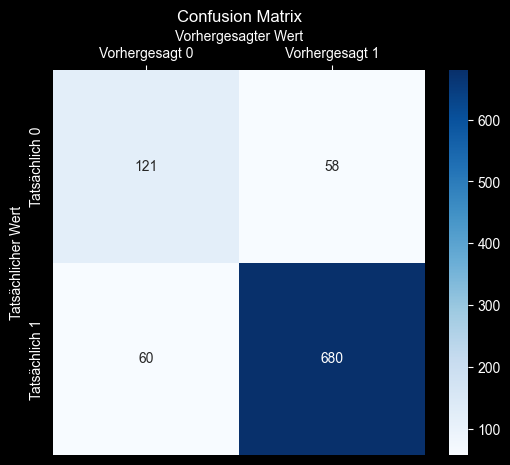

In [11]:
# Confusion Matrix ausgeben

# Matrix berechnen
cm = confusion_matrix(y_test, y_pred)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
            yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])

# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

plt.ylabel('Tatsächlicher Wert')
plt.xlabel('Vorhergesagter Wert')
plt.title('Confusion Matrix')
plt.show()

In [12]:
'''
# -> je nach Modell kommen andere Feature Importances raus

# Modell trainieren V2 (mit scale_pos_weight)
# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind

# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.
def get_class_weights(y):
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()

    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")

    # scale_pos_weight = count_neg / count_pos
    weight = count_0 / count_1
    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")

    return weight


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Gewichtung berechnen
scale_pos = get_class_weights(y_train)

# Modell mit Gewichtung initialisieren
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import f1_score, roc_auc_score
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Loggen

experiment_logs = []
def log_experiment(params, metrics):
    log_entry = {'params': params, 'metrics': metrics}
    experiment_logs.append(log_entry)


log_experiment(
    params={'window_size': 10, 'max_depth': 5},
    metrics={
        'auc': roc_auc_score(y_test, y_proba),
        'f1': f1_score(y_test, y_pred)
    }
)
'''

'\n# -> je nach Modell kommen andere Feature Importances raus\n\n# Modell trainieren V2 (mit scale_pos_weight)\n# scale_pos_weight hilft, falls die Klassen (Tinnitus vs. kein Tinnitus) ungleich verteilt sind\n\n# Berechnet das Verhältnis von 0 zu 1 von q1 für XGBoost.\ndef get_class_weights(y):\n    count_0 = (y == 0).sum()\n    count_1 = (y == 1).sum()\n\n    print(f"Verteilung der Daten: Klasse 0 = {count_0}, Klasse 1 = {count_1}")\n\n    # scale_pos_weight = count_neg / count_pos\n    weight = count_0 / count_1\n    print(f"Berechnetes scale_pos_weight für XGBoost: {weight:.4f}")\n\n    return weight\n\n\nfrom xgboost import XGBClassifier\nfrom sklearn.metrics import classification_report, roc_auc_score\n\n# Gewichtung berechnen\nscale_pos = get_class_weights(y_train)\n\n# Modell mit Gewichtung initialisieren\nmodel = XGBClassifier(\n    n_estimators=100,\n    max_depth=5,\n    scale_pos_weight=scale_pos, # Hier wird die Gewichtung angewendet\n    eval_metric=\'logloss\'\n)\n\nmodel

In [13]:
'''
# zu: Modell trainieren V2

print(f"\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
'''

'\n# zu: Modell trainieren V2\n\nprint(f"\nKlassifikationsbericht:")\nprint(classification_report(y_test, y_pred))\nprint(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")\n'

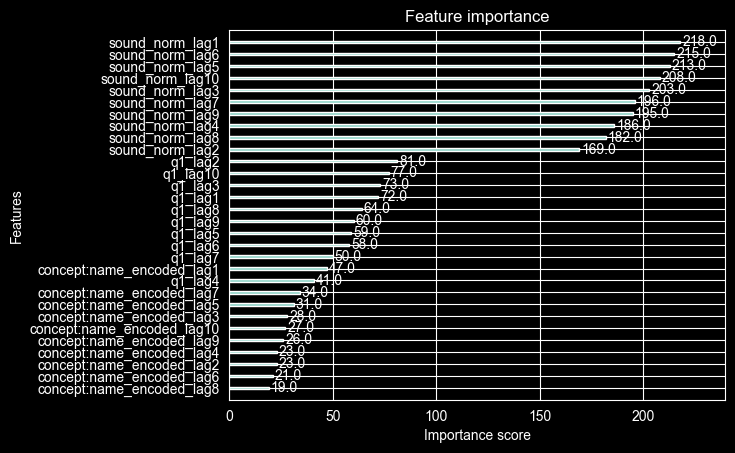

In [14]:
# schauen, was XGBoost genau gemacht hat
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=30) # Top X Features
plt.show()

In [15]:
# lag1 ist der letzte Eintrag vor dem zu Prognostizierenden. lag10 ist der 10. Eintrag vor dem zu Prognostizierenden.
# je größer "Importance Score", desto wichtiger ist dieser Wert für die Prognose.

# Random Forest

In [16]:
# Initialisierung
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Training
model_rf.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Klassifikationsbericht:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Klassifikationsbericht:
              precision    recall  f1-score   support

         0.0       0.70      0.64      0.67       179
         1.0       0.92      0.93      0.92       740

    accuracy                           0.88       919
   macro avg       0.81      0.79      0.80       919
weighted avg       0.87      0.88      0.87       919

ROC-AUC Score: 0.8982


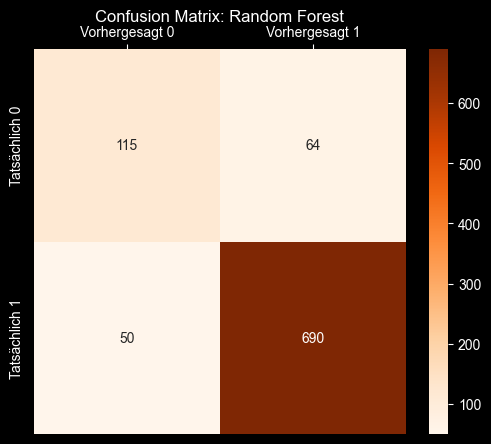

In [17]:
# Confusion Matrix ausgeben

# Matrix berechnen
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
                 xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
                 yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])
# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Confusion Matrix: Random Forest', pad=20)
plt.show()

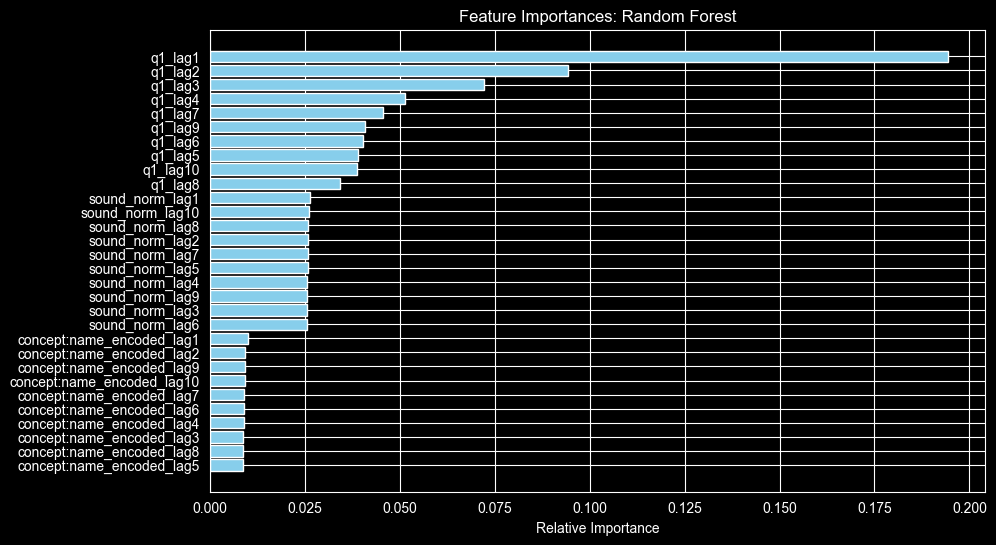

In [18]:
# schauen, was der Random Forest genau gemacht hat

# Feature Importance Plot (Ähnlich zu XGBoost)
importances = model_rf.feature_importances_
indices = np.argsort(importances)[-30:] # Top X Features

plt.figure(figsize=(10, 6))
plt.title('Feature Importances: Random Forest')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# ? SVM ?

In [19]:
'''
# SVM falls Laptop das packt und es überhaupt Sinn macht

from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialisierung
# 'probability=True' ist wichtig, damit wir später den ROC-AUC Score (Wahrscheinlichkeiten) berechnen können.
# 'kernel=rbf' ist der Standard (Radial Basis Function), der auch nicht-lineare Muster erkennt.
model_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# Training
model_svm.fit(X_train, y_train)

# Vorhersage auf dem Testset
y_pred_svm = model_svm.predict(X_test)
y_proba_svm = model_svm.predict_proba(X_test)[:, 1]

# Evaluation
print("SVM Klassifikationsbericht:")
print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_svm):.4f}")

# Confusion Matrix ausgeben

# Matrix berechnen
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Heatmap erstellen
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
                 xticklabels=['Vorhergesagt 0', 'Vorhergesagt 1'],
                 yticklabels=['Tatsächlich 0', 'Tatsächlich 1'])
# Label und Ticks nach oben
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.title('Confusion Matrix: SVM', pad=20)
plt.show()
'''

'\n# SVM falls Laptop das packt und es überhaupt Sinn macht\n\nfrom sklearn.svm import SVC\nfrom sklearn.metrics import classification_report, roc_auc_score, confusion_matrix\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Initialisierung\n# \'probability=True\' ist wichtig, damit wir später den ROC-AUC Score (Wahrscheinlichkeiten) berechnen können.\n# \'kernel=rbf\' ist der Standard (Radial Basis Function), der auch nicht-lineare Muster erkennt.\nmodel_svm = SVC(kernel=\'rbf\', class_weight=\'balanced\', probability=True, random_state=42)\n\n# Training\nmodel_svm.fit(X_train, y_train)\n\n# Vorhersage auf dem Testset\ny_pred_svm = model_svm.predict(X_test)\ny_proba_svm = model_svm.predict_proba(X_test)[:, 1]\n\n# Evaluation\nprint("SVM Klassifikationsbericht:")\nprint(classification_report(y_test, y_pred_svm))\nprint(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_svm):.4f}")\n\n# Confusion Matrix ausgeben\n\n# Matrix berechnen\ncm_svm = confusion_matrix(y_test, y_pred_svm